# 07 · Metals — geometries, isomers, chelates, TS, binding modes

A metal centre becomes a UFF-typeable **carbon surrogate** (bonds stripped), held by distance + angle constraints for the chosen polyhedron, then restored — plain RDKit, no xtb. `rx.metal(smiles, geometry)` enumerates the distinct **coordination isomers** as an `IsomerSet` to pick from.

**Rendering note.** xyzrender detects ordinary bonds (including metal–donor coordination) from the geometry on its own — we only name the *special* ones: **non-covalent contacts** (H-bonds, chalcogen, cation-π) via `nci_bonds=[(i, j)]` (dotted), and **genuine forming/breaking TS bonds** via `ts_bonds=[(i, j)]` (dashed). Distances/angles are labelled with `labels=["i j d"]` / `"i j k a"`. xyzrender is 1-indexed, so atom indices are passed `+1`.

In [1]:
import tempfile
import numpy as np
import rxembed as rx
import xyzrender
from rdkit import RDLogger
from rdkit.Chem import rdMolTransforms as T
from rxembed.constraints.metal import metal_indices
from rxembed.embed.dispatch import _xyz_to_mol

RDLogger.DisableLog("rdApp.*")
rx.set_verbose("INFO")


def xyz(ens):
    return ens.lowest(1).dump(tempfile.mktemp(suffix=".xyz"))  # 1 conformer -> a path xyzrender reads


def mxyz(ens):
    return ens.dump(tempfile.mktemp(suffix=".xyz"))

## Coordination isomers — the permutations

Square-planar MA₂B₂ → **cis / trans**; octahedral MA₃B₃ → **mer / fac**. `.summary()` tags each with its **per-vertex arrangement** and Λ/Δ **chirality** — the unambiguous, name-agnostic identity. Pick one with `.select(index=…)`, `.select(arrangement=…)`, or `.select(chirality=…)` (the coarse cis/trans/mer/fac name is intentionally not the selector — it's ambiguous once several isomers share it).

In [2]:
print("square-planar Pd (cis/trans):")
rx.metal("CCCN[Pd](Cl)(Cl)NCCC", "square_planar").summary()
print("\noctahedral Co(NH3)3Cl3 (mer/fac):")
rx.metal("N[Co](N)(N)(Cl)(Cl)Cl", "octahedral").summary()

square-planar Pd (cis/trans):
  [0] square_planar    N3 Cl5 Cl6 N7              (achiral)
  [1] square_planar    N3 Cl6 N7 Cl5              (achiral)

octahedral Co(NH3)3Cl3 (mer/fac):
  [0] octahedral       N0 N2 N3 Cl4 Cl5 Cl6       (achiral)
  [1] octahedral       N0 Cl4 N3 Cl5 N2 Cl6       (achiral)


[Isomer(mol=<rdkit.Chem.rdchem.Mol object at 0x7f3b60cd7ba0>, cons=Constraints(distances={(0, 1): (1.8653143000000003, 1.9653143000000004), (1, 2): (1.8653143000000003, 1.9653143000000004), (1, 3): (1.8653143000000003, 1.9653143000000004), (1, 4): (2.1488620000000003, 2.248862), (1, 5): (2.1488620000000003, 2.248862), (1, 6): (2.1488620000000003, 2.248862)}, angles={(0, 1, 2): (172.0, 180.0), (3, 1, 4): (172.0, 180.0), (5, 1, 6): (172.0, 180.0), (0, 1, 3): (82.0, 98.0), (2, 1, 5): (82.0, 98.0), (4, 1, 6): (82.0, 98.0)}, planes=[], coplanar=[], frozen=set(), contacts=(frozenset(), frozenset()), metals={1}, pulls={(0, 1): 1.9153143000000004, (1, 2): 1.9153143000000004, (1, 3): 1.9153143000000004, (1, 4): 2.198862, (1, 5): 2.198862, (1, 6): 2.198862}, floors={}, dg_floors={(1, 7): 1.6485, (1, 8): 1.6485, (1, 9): 1.6485, (1, 10): 1.6485, (1, 11): 1.6485, (1, 12): 1.6485}, shapes=[]), metal=1, donors=[0, 2, 3, 4, 5, 6], real_z=27, real_q=0, label='mer', geometry='octahedral', vertices=[0, 2

The **fac** Co isomer: the coordination sphere drawn as dotted dative bonds (`nci_bonds`) makes the 3 N / 3 Cl faces obvious; element labels via `idx='s'`.

rxembed | embed[octahedral: N0 Cl4 N3 Cl5 N2 Cl6]: 11 seeds


rxembed | mc: 7 atom(s) constrained -> openconf runs POSE-FROZEN (rotor-only; low-mode/ring/global moves off) so the held contact is never broken
rxembed | mc: +1 (openconf 'ensemble', pose-constrained around seeds; total 12)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0] | window=250 -> all within window
rxembed | minimize: re-embedded to 12/12 clean geometries
rxembed | prune[rmsd]: 12 -> 2  (merged 10 near-duplicates; see .duplicates())


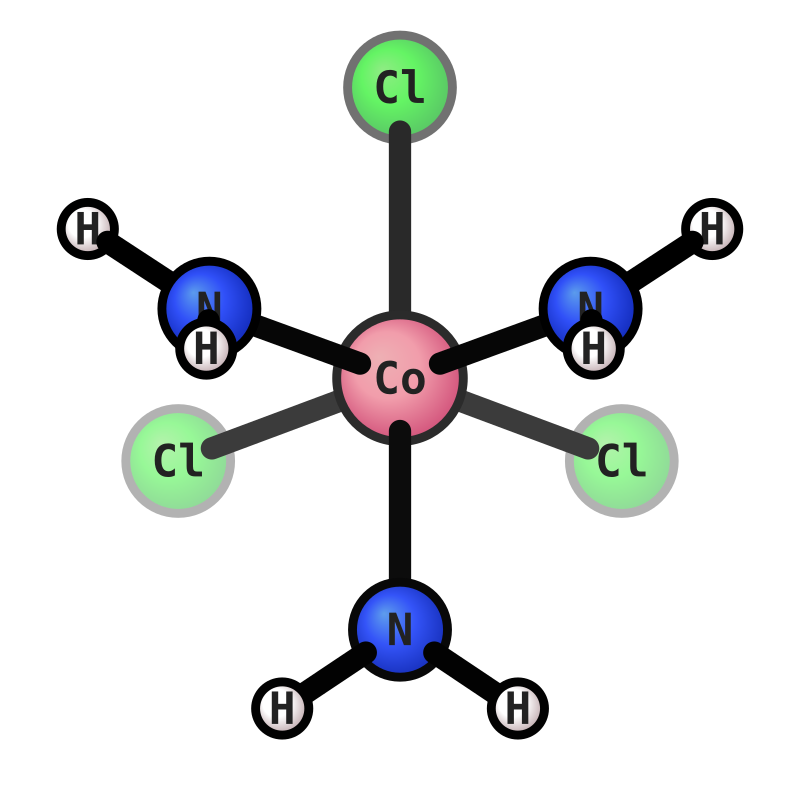

In [3]:
co = rx.metal("N[Co](N)(N)(Cl)(Cl)Cl", "octahedral").select(index=1)  # the fac isomer (index 1 in .summary())
ens = rx.embed(co).mc(preset="ensemble").prune()
p = xyz(ens)
xyzrender.render(p, no_hy=True, idx="s")

The **trans** Pd isomer — the two Cl sit ~180° across the metal (labelled Cl–Pd–Cl angle).

rxembed | embed[square_planar: N3 Cl6 N7 Cl5]: 40 seeds


rxembed | mc: 7 atom(s) constrained -> openconf runs POSE-FROZEN (rotor-only; low-mode/ring/global moves off) so the held contact is never broken
rxembed | mc: +47 (openconf 'ensemble', pose-constrained around seeds; total 87)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.5, 0.5, 0.6, 0.7, 0.8, 0.8, 0.8, 0.8, 1.0, 1.1, 1.1, 1.1, 1.1, 1.2, 1.3, 1.3, 1.3, 1.4, 1.4, 1.4, 1.6, 1.6, 1.6, 1.6, 1.6, 1.6, 1.7, 1.7, 1.7, 1.7, 1.8, 1.8, 1.8, 1.8, 1.8, 1.9, 1.9, 1.9, 1.9, 1.9, 1.9, 1.9, 1.9, 1.9, 2.0, 2.0, 2.1, 2.1, 2.1, 2.1, 2.1, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.2, 2.3, 2.3, 2.3, 2.3, 2.4, 2.4, 2.4, 2.4, 2.6, 2.6, 2.6, 2.6, 2.6, 2.6, 2.8, 2.8, 2.8, 2.9, 3.0, 3.1, 3.1, 3.1, 3.2, 3.3, 3.3, 3.3, 3.5, 3.7] | window=250 -> all within window
rxembed | minimize: re-embedded to 87/87 clean geometries
rxembed | prune[rmsd]: 87 -> 64  (merged 23 near-duplicates; see .duplicates())


64 conformers | Cl-Pd-Cl = 172° (trans)


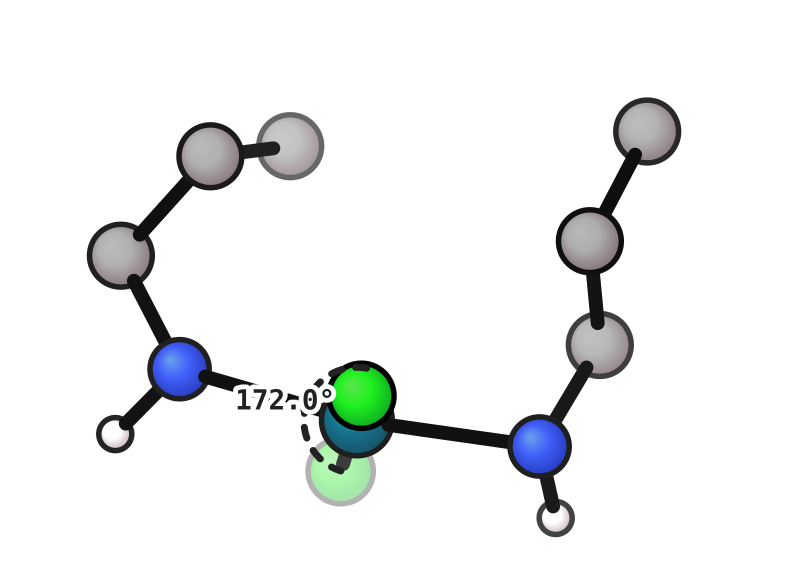

In [4]:
trans = rx.metal("CCCN[Pd](Cl)(Cl)NCCC", "square_planar").select(index=1)  # the trans isomer (index 1)
ens = rx.embed(trans).mc(preset="ensemble").prune()
cl = [d for d in trans.donors if ens.mol.GetAtomWithIdx(d).GetSymbol() == "Cl"]
print(f"{len(ens)} conformers | Cl-Pd-Cl = {ens.measure((cl[0], trans.metal, cl[1]))['mean']:.0f}° (trans)")
p = xyz(ens)
xyzrender.render(
    p, no_hy=True, labels=[f"{cl[0] + 1} {trans.metal + 1} {cl[1] + 1} a"]
)  # label the trans Cl-Pd-Cl angle

## Across coordination geometries

One surface spans the polyhedra — linear, tetrahedral, square-planar, octahedral (and trigonal-bipyramidal / square-pyramidal for 5-coordinate).

In [5]:
for g, smi in {
    "linear": "[Cl][Au][Cl]",
    "tetrahedral": "Cl[Zn](Cl)(Cl)Cl",
    "square_planar": "CCCN[Pd](Cl)(Cl)NCCC",
    "octahedral": "N[Co](N)(N)(Cl)(Cl)Cl",
}.items():
    isos = rx.metal(smi, g)
    print(f"  {g:14s}: {len(isos)} isomer(s) {[i.label for i in isos]}")

  linear        : 1 isomer(s) ['']
  tetrahedral   : 1 isomer(s) ['']
  square_planar : 2 isomer(s) ['cis', 'trans']
  octahedral    : 2 isomer(s) ['mer', 'fac']


## Metal-centre chirality — Λ / Δ, and the robust conformer pipeline

A bis/tris-chelate metal can be a genuine stereocentre with **no organic stereocentre in sight** — the handedness of the coordination sphere itself. rxembed tags it Λ/Δ (a point-group-parity descriptor), so `[Co(en)₂Cl₂]` enumerates the textbook three: **trans** (achiral) and the enantiomeric **cis-Δ / cis-Λ**. Select on `chirality=`. Then run the full metal conformer pipeline — **relax the seeds → MC search → re-relax → dedup** (`embed(n).minimize().mc().minimize().prune()`) — pull the distinct modes with `representatives()`, and grab one by position with `reps[i]`.

rxembed | embed[octahedral: Cl0 N3 Cl2 N7 N6 N10 Δ]: 7 seeds


  [0] octahedral       Cl0 Cl2 N3 N7 N6 N10       (achiral)
  [1] octahedral       Cl0 N3 Cl2 N7 N6 N10       Δ
  [2] octahedral       Cl0 N7 N3 N10 Cl2 N6       Λ


rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.0, 0.0, 0.0, 0.3, 0.3, 0.5] | window=250 -> all within window
rxembed | minimize: re-embedded to 7/7 clean geometries
rxembed | mc: 11 atom(s) constrained -> openconf runs POSE-FROZEN (rotor-only; low-mode/ring/global moves off) so the held contact is never broken
rxembed | mc: +1 (openconf 'ensemble', pose-constrained around seeds; total 8)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.3, 0.3, 0.3, 0.5, 0.5, 0.5, 0.5] | window=250 -> all within window
rxembed | prune[rmsd]: 8 -> 2  (merged 6 near-duplicates; see .duplicates())
rxembed | representatives: 1 ligand arrangement mode(s)


cis-Δ [Co(en)2Cl2]: 2 conformers -> 1 distinct mode(s)


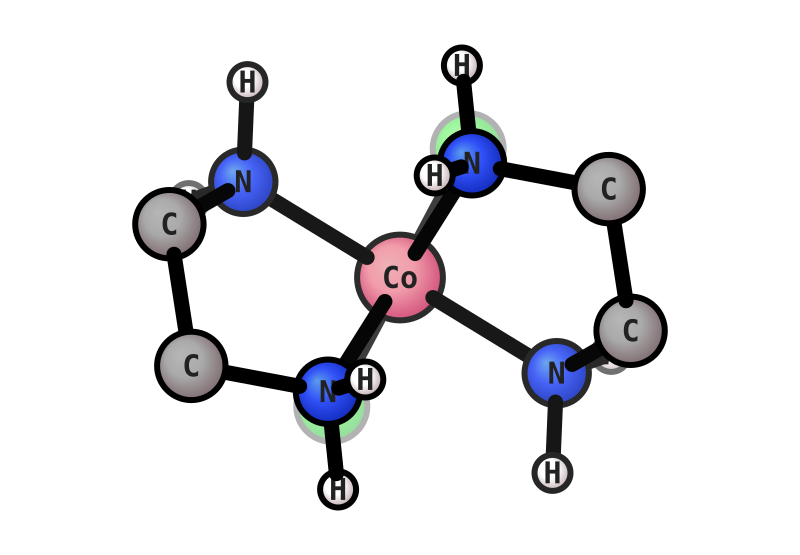

In [12]:
isos = rx.metal("Cl[Co]12(Cl)(<-NCC<-N1)<-NCC<-N2", "octahedral")  # [Co(en)2Cl2] — bis-chelate + 2 Cl
isos.summary()  # trans | achiral ;  cis | Δ ;  cis | Λ
delta = isos.select(chirality="Δ")  # pick the Δ enantiomer by its handedness (name-agnostic, unambiguous)
ens = rx.embed(delta, n=8).minimize().mc(preset="ensemble").minimize().prune()  # relax -> search -> re-relax -> dedup
reps = ens.representatives()
print(f"cis-Δ [Co(en)2Cl2]: {ens.n} conformers -> {reps.n} distinct mode(s)")
xyzrender.render(reps[0].dump(tempfile.mktemp(suffix=".xyz")), no_hy=True, idx="s")  # reps[0] — the new [i] indexing

## Chelating ligands — bidentate

A chelate's donors sit on one ligand fragment; rxembed detects same-fragment donors and widens their L–M–L window (a rigid backbone bite is distorted off the ideal) while still separating cis from trans. Ethylenediamine on Pd (a 5-membered chelate ring, N–Pd–N bite ~82°) + two chloride:

rxembed | embed[square_planar: Br0 Cl2 N3 N6]: 10 seeds
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.0, 0.0, 0.0, 0.0, 6.5, 6.5, 6.5, 6.5, 6.6] | window=250 -> all within window
rxembed | minimize: re-embedded to 10/10 clean geometries
rxembed | mc: 7 atom(s) constrained -> openconf runs POSE-FROZEN (rotor-only; low-mode/ring/global moves off) so the held contact is never broken
rxembed | mc: +1 (openconf 'ensemble', pose-constrained around seeds; total 11)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.0, 0.0, 0.0, 0.0, 0.1, 1.1, 1.1, 1.1, 6.5, 6.5] | window=250 -> all within window
rxembed | prune[rmsd]: 11 -> 2  (merged 9 near-duplicates; see .duplicates())


2 conformers | en bite N-Pd-N = 85°


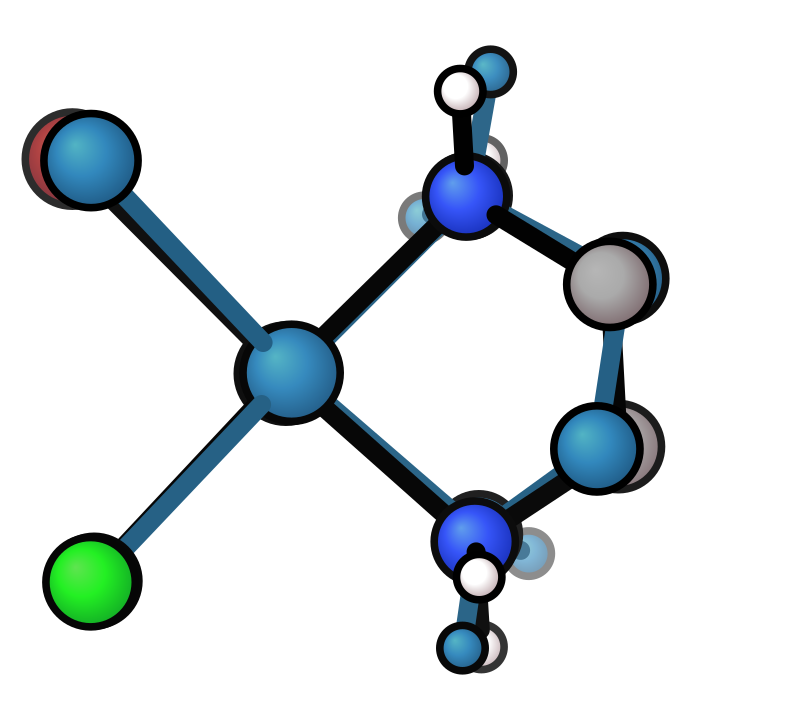

In [15]:
en = rx.metal("Br[Pd]1(Cl)<-NCC<-N1", "square_planar")  # the NCCN ring pins both N to Pd
iso = en.select()
ens = rx.embed(iso, n=10).minimize().mc(preset="ensemble").minimize().prune()
nn = [d for d in iso.donors if ens.mol.GetAtomWithIdx(d).GetSymbol() == "N"]
print(f"{len(ens)} conformers | en bite N-Pd-N = {ens.measure((nn[0], iso.metal, nn[1]))['mean']:.0f}°")
xyzrender.render(
    xyzrender.load(
        ens.dump(tempfile.mktemp(suffix=".xyz")), ensemble=len(ens) > 1, ensemble_color="spectral", nci_detect=True
    ),
    no_hy=True,
)

## Side-on η² coordination

When a ligand's two coordinating atoms are **directly π-bonded** (an alkene, alkyne, imine, phosphaalkene), it binds *side-on* — both atoms grip through the π bond. rxembed detects the multiple-bonded donor pair and **holds that bond at its natural length**, so the two metal pulls can't stretch the C=C / C≡C apart (which would otherwise tear it and blow the coordination sphere out). Here a Ni acyl-malonate with a side-on C=C: both Ni–C distances bind and the double bond stays intact.

rxembed | metal: 1 undefined ligand stereocentre(s) -> enumerating coordination x 2 ligand stereoisomer(s) = 2 candidate(s) (select stereo=)


rxembed | embed[square_planar: C4 C23 O6 N16]: 8 seeds
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 1.4, 8.0, 9.3, 15.8, 22.1, 25.6] | window=250 -> all within window
rxembed | minimize: dropped 1 conformer(s) (1x broken bond) -> 7 kept
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 4.5] | window=250 -> all within window
rxembed | minimize: dropped 1 conformer(s) (1x broken bond) -> 2 kept
rxembed | minimize: re-embedded to 8/8 clean geometries
rxembed | mc: 8 atom(s) constrained -> openconf runs POSE-FROZEN (rotor-only; low-mode/ring/global moves off) so the held contact is never broken
rxembed | mc: +8 (openconf 'ensemble', pose-constrained around seeds; total 16)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 2.1, 2.8, 3.1, 3.3, 3.7, 4.3, 5.6, 10.2, 14.4, 67.1, 96.3, 296381399422.2] | window=250 -> dropping 1 un-converged: [296381399422.2]
rxembed | minimize: dropped 4 conformer(s) (3x broken bond, 1x non-physical relax energy) ->

side-on C=C (4, 23): 12 confs | Ni-C 2.04/2.04 Å (both bind) | C=C 1.47 Å (held intact)


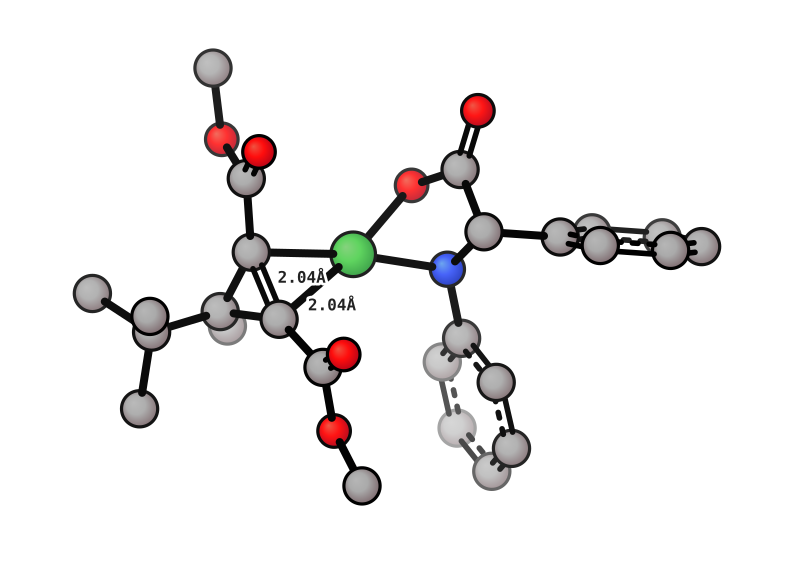

In [16]:
iso = rx.metal(
    "COC(=O)[C]12->[Ni+2]3(<-[O-]C(=O)C(c4ccccc4)[N-]->3c3ccccc3)<-[C]=1(C(=O)OC)C2(C)C(C)(C)C",
    "square_planar",
).select(index=0)
pi = next(  # the directly π-bonded donor pair — the side-on C=C
    (a, b)
    for a in iso.donors
    for b in iso.donors
    if a < b and (bd := iso.mol.GetBondBetweenAtoms(a, b)) and bd.GetBondTypeAsDouble() >= 2
)
ens = rx.embed(iso, n=8).minimize().mc(preset="ensemble").minimize().prune()
c = ens.mol.GetConformer(ens.ids[0])
print(
    f"side-on C=C {pi}: {ens.n} confs | Ni-C {T.GetBondLength(c, iso.metal, pi[0]):.2f}/"
    f"{T.GetBondLength(c, iso.metal, pi[1]):.2f} Å (both bind) | C=C {T.GetBondLength(c, *pi):.2f} Å (held intact)"
)
xyzrender.render(xyz(ens), no_hy=True, labels=[f"{iso.metal + 1} {pi[0] + 1} d", f"{iso.metal + 1} {pi[1] + 1} d"])

## Vacant sites — a coordination pocket

Name a geometry with **more vertices than donors** and the empty vertex is left as a pocket (`·` in the arrangement) for a substrate to bind later. A 3-donor Pd in a square-planar field leaves one site open.

rxembed | metal[square_planar]: 4 sites, 3 donors -> 1 vacant site(s) (coordination pocket)
rxembed | embed[square_planar: N2 Cl4 Cl5 ·]: 22 seeds
rxembed | mc: 5 atom(s) constrained -> openconf runs POSE-FROZEN (rotor-only; low-mode/ring/global moves off) so the held contact is never broken
rxembed | mc: +1 (openconf 'ensemble', pose-constrained around seeds; total 23)


  [0] square_planar    N2 Cl4 Cl5 ·               (achiral)
  [1] square_planar    N2 Cl5 · Cl4               (achiral)


rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.1] | window=250 -> all within window
rxembed | minimize: re-embedded to 23/23 clean geometries
rxembed | prune[rmsd]: 23 -> 1  (merged 22 near-duplicates; see .duplicates())


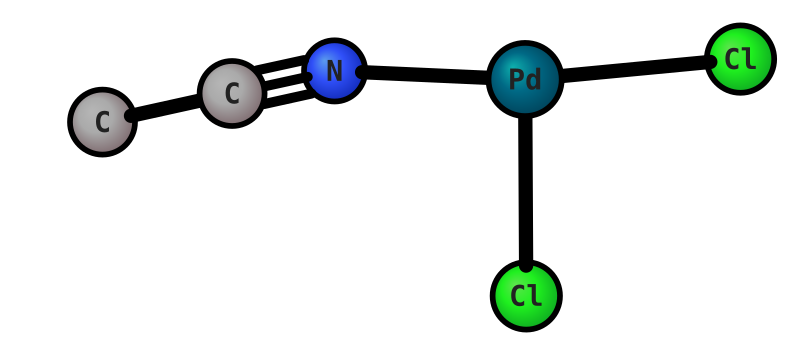

In [18]:
pocket = rx.metal("CC#N->[Pd](Cl)Cl", "square_planar")  # N + 2 Cl = 3 donors, 4 vertices
pocket.summary()  # '·' marks the vacant coordination site
iso = pocket.select(index=0)  # the cis pocket (both Cl cis; the '·' vacancy sits opposite the lone Cl)
ens = rx.embed(iso).mc(preset="ensemble").prune()
xyzrender.render(xyz(ens), no_hy=True, idx="s")  # the '·' vacancy sits opposite the lone Cl

## A real metal TS — reacting core frozen, spectator ferrocene held

A **bimetallic** Mn/Fe transition state: H₂ activation at Mn (H–H breaking, Mn–H / substrate N–H, O–H forming), with a *spectator* ferrocene. Freeze the reacting core — grafted back to **0.000 Å** on every pose while the periphery is searched; both metals restored. Here `ts_bonds=` is genuinely correct (real forming/breaking bonds), labelled with their live lengths — note the ~0.86 Å H–H being cleaved.

rxembed | resolve: graft C1, N5, H63, H64, H65, O66


metals: [(0, 'Fe'), (1, 'Mn')]


rxembed | embed: 6 seeds (78 atoms, 7 fragments, 88 constraints)
rxembed | mc: 21 atom(s) constrained -> openconf runs POSE-FROZEN (rotor-only; low-mode/ring/global moves off) so the held contact is never broken
rxembed | mc: +3 (openconf 'ensemble', pose-constrained around seeds; total 9)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 1.8, 13.0] | window=250 -> all within window
rxembed | minimize: dropped 6 conformer(s) (6x torn rigid body) -> 3 kept
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 26.3, 116.1, 138.3] | window=250 -> all within window
rxembed | minimize: dropped 7 conformer(s) (7x torn rigid body) -> 4 kept
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 6.7, 28.5] | window=250 -> all within window
rxembed | minimize: dropped 8 conformer(s) (8x torn rigid body) -> 3 kept
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 15.3, 45.2, 62.1, 78.3, 105.3] | window=250 -> all within window
rxembed | minimize: dr

2 conformers | reacting core held to 0.0000 Å | metals: ['Fe', 'Mn']


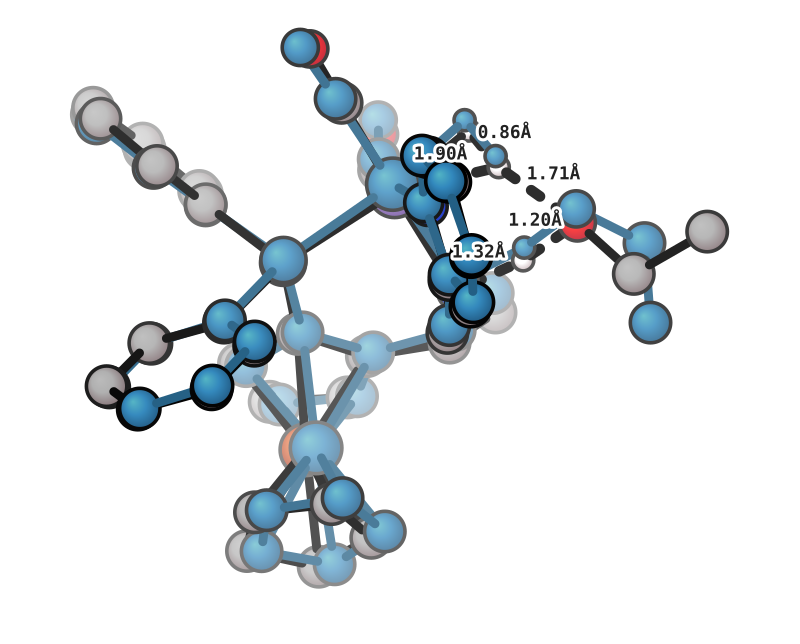

In [19]:
mn = "structures/mn-h2.xyz"
rc = [1, 5, 63, 64, 65, 66]  # reacting-core atoms (from a graphrc trajectory in practice)
bonds = [(5, 65), (64, 66), (1, 64), (65, 66), (63, 64)]  # forming / breaking bonds held during embed
Pin = _xyz_to_mol(mn, 0).GetConformer().GetPositions()
print("metals:", [(i, _xyz_to_mol(mn, 0).GetAtomWithIdx(i).GetSymbol()) for i in metal_indices(_xyz_to_mol(mn, 0))])
ens = rx.embed(mn, fix=rc, n=6).mc(preset="ensemble").prune()
drift = max(
    abs(T.GetBondLength(ens.mol.GetConformer(c), i, j) - float(np.linalg.norm(Pin[i] - Pin[j])))
    for c in ens.ids
    for i, j in bonds
)
print(
    f"{len(ens)} conformers | reacting core held to {drift:.4f} Å | "
    f"metals: {[ens.mol.GetAtomWithIdx(i).GetSymbol() for i in metal_indices(ens.mol)]}"
)
xyzrender.render(
    xyzrender.load(mxyz(ens), ensemble=len(ens) > 1, ensemble_color="spectral"),  # guard: ensemble needs >=2 frames
    no_hy=True,
    ts_bonds=[(i + 1, j + 1) for i, j in bonds],
    labels=[f"{i + 1} {j + 1} d" for i, j in bonds],
)

With the reacting core frozen, the **free** coordination sites around Mn are enumerated (mer/fac of the spectators). One arrangement (`fac1`) is geometrically infeasible and embeds to 0 conformers — honestly reported, not hidden — while **mer** embeds cleanly:

rxembed | metal: enumerating Mn1; holding 1 spectator metal(s) by 55 shape constraints
rxembed | resolve: graft C1, N5, H63, H64, H65, O66
rxembed | metal: fixing 6 atom(s) at the input geometry; enumerating the free coordination sites around them
rxembed | metal[octahedral]: 2 frozen donor(s) pinned at input vertices; 24 free-site arrangement(s) to dedup
rxembed | embed[octahedral: C62 N6 C61 N5 P2 H63 Λ]: 2 seeds
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run
rxembed | mc: 21 atom(s) constrained -> openconf runs POSE-FROZEN (rotor-only; low-mode/ring/global moves off) so the held contact is never broken
rxembed | mc: +1 (openconf 'rapid', pose-constrained around seeds; total 3)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window
rxembed | minimize: dropped 2 conformer(s) (2x broken bond) -> 1 kept
rxembed | minimize: relax ΔE sprea

  fac1  :  1 confs | core held 0.0000 Å


rxembed | mc: +5 (openconf 'rapid', pose-constrained around seeds; total 7)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 9.8, 11.9, 13.1, 17.1, 18.1] | window=250 -> all within window
rxembed | minimize: dropped 1 conformer(s) (1x broken bond) -> 6 kept
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 250.4, 419.3, 591.4, 675.5] | window=250 -> dropping 4 un-converged: [250.4, 419.3, 591.4, 675.5]
rxembed | minimize: dropped 8 conformer(s) (3x broken bond, 1x torn rigid body, 4x non-physical relax energy) -> 1 kept
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 71.2, 634.5, 717.4, 996.7] | window=250 -> dropping 3 un-converged: [634.5, 717.4, 996.7]
rxembed | minimize: dropped 7 conformer(s) (3x broken bond, 1x torn rigid body, 3x non-physical relax energy) -> 2 kept
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 745.6] | window=250 -> dropping 1 un-converged: [745.6]
rxembed | minimize: dropped 8 conformer(s) (5x brok

  fac2  :  0 confs | core held 0.0000 Å


rxembed | embed[octahedral: N6 C62 C61 N5 P2 H63 Δ]: 2 seeds
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run
rxembed | mc: 21 atom(s) constrained -> openconf runs POSE-FROZEN (rotor-only; low-mode/ring/global moves off) so the held contact is never broken
rxembed | mc: +5 (openconf 'rapid', pose-constrained around seeds; total 7)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.7, 3.2, 12.2, 14.6, 24.6, 39.8] | window=250 -> all within window
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 2.4, 246.9] | window=250 -> all within window
rxembed | minimize: dropped 6 conformer(s) (5x broken bond, 1x torn rigid body) -> 3 kept
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 498.6, 512.0, 647.4] | window=250 -> dropping 3 un-converged: [498.6, 512.0, 647.4]
rxembed | minimize: dropped 8 conformer(s) (4x broken bond, 1x torn rigid body, 

...

rxembed | embed[octahedral: P2 C62 C61 N5 N6 H63 Λ]: 2 seeds
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run
rxembed | mc: 21 atom(s) constrained -> openconf runs POSE-FROZEN (rotor-only; low-mode/ring/global moves off) so the held contact is never broken
rxembed | mc: +1 (openconf 'rapid', pose-constrained around seeds; total 3)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window
rxembed | minimize: dropped 2 conformer(s) (1x broken bond, 1x torn rigid body) -> 1 kept
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window
rxembed | minimize: dropped 4 conformer(s) (3x broken bond, 1x torn rigid body) -> 1 kept
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 305.4] | window=250 -> dropping 1 un-converged: [305.4]
rxembed | minimize: dropped 4 conformer(s) (2x broken bond, 1x t

  fac4  :  1 confs | core held 0.0000 Å


rxembed | embed[octahedral: P2 N6 C62 N5 C61 H63 Λ]: 2 seeds
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run
rxembed | mc: 21 atom(s) constrained -> openconf runs POSE-FROZEN (rotor-only; low-mode/ring/global moves off) so the held contact is never broken
rxembed | mc: +1 (openconf 'rapid', pose-constrained around seeds; total 3)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window
rxembed | minimize: dropped 2 conformer(s) (2x broken bond) -> 1 kept
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 369.2, 679.4, 1397.0] | window=250 -> dropping 3 un-converged: [369.2, 679.4, 1397.0]
rxembed | minimize: dropped 4 conformer(s) (1x torn rigid body, 3x non-physical relax energy) -> 1 kept
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 557.5] | window=250 -> dropping 1 un-converged: [557.5]
rxembed | minimize

  mer2  :  1 confs | core held 0.0000 Å


rxembed | embed[octahedral: N6 P2 C62 N5 C61 H63 Δ]: 3 seeds
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run
rxembed | mc: 21 atom(s) constrained -> openconf runs POSE-FROZEN (rotor-only; low-mode/ring/global moves off) so the held contact is never broken
rxembed | mc: +1 (openconf 'rapid', pose-constrained around seeds; total 4)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 8.8] | window=250 -> all within window
rxembed | minimize: dropped 2 conformer(s) (2x broken bond) -> 2 kept
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 131.6] | window=250 -> all within window
rxembed | minimize: dropped 4 conformer(s) (3x broken bond, 1x torn rigid body) -> 2 kept
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 353.2, 367.8, 477.2, 3084.2, 6023.3] | window=250 -> dropping 5 un-converged: [353.2, 367.8, 477.2, 3084.2, 6023.3]
rxembed | mi

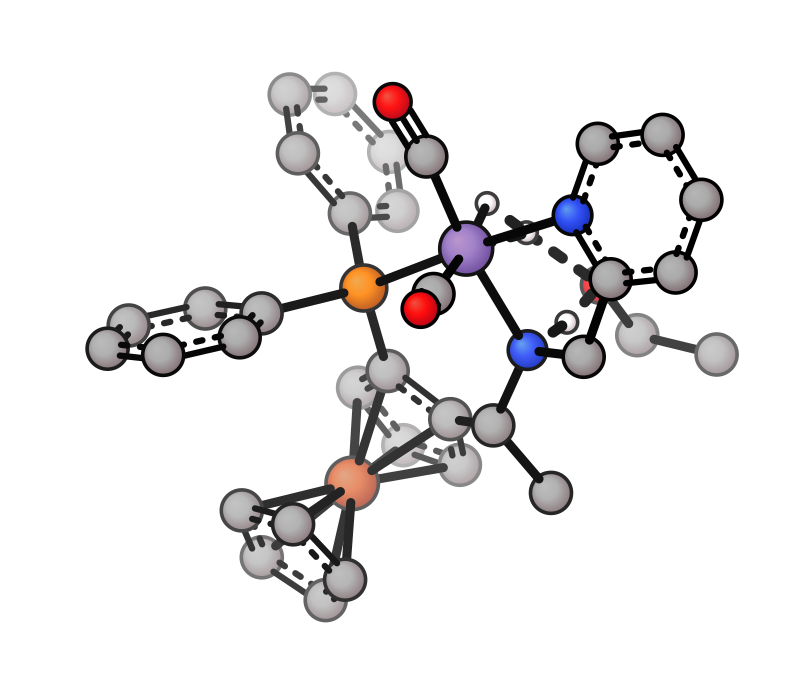

In [20]:
isos = rx.metal(mn, "octahedral", center="Mn", fix=rc)
for iso in isos:
    e = rx.embed(iso, n=2).mc(preset="rapid").prune()
    d = max(
        (
            abs(T.GetBondLength(e.mol.GetConformer(c), i, j) - float(np.linalg.norm(Pin[i] - Pin[j])))
            for c in e.ids
            for i, j in bonds
        ),
        default=0.0,
    )
    print(f"  {iso.label:6s}: {len(e):2d} confs | core held {d:.4f} Å")
mer = rx.embed(isos[3], n=3).mc(preset="rapid").prune()
xyzrender.render(xyz(mer), no_hy=True, ts_bonds=[(i + 1, j + 1) for i, j in bonds])  # the mer isomer

The same frozen-TS machinery spans very different real organometallic TS (core held to 0.000 Å, every metal restored): **mn-h2** (H₂ activation, 78 atoms), **mn-hy** (a larger Mn hydride, 95 atoms), **ru-co** (a Ru carbonyl TS, 72 atoms).

In [21]:
META = {  # reacting core + forming/breaking bonds per TS (from graphrc trajectories in practice)
    "mn-h2": {"rc": [1, 5, 63, 64, 65, 66], "bonds": [(5, 65), (64, 66), (1, 64), (65, 66), (63, 64)], "natoms": 78},
    "mn-hy": {"rc": [1, 67, 77], "bonds": [(67, 77), (1, 67)], "natoms": 95},
    "ru-co": {"rc": [0, 3, 63, 64, 66], "bonds": [(0, 64), (64, 66), (0, 63), (3, 66)], "natoms": 72},
}
for name in ["mn-h2", "mn-hy", "ru-co"]:
    rc2 = META[name]["rc"]
    b2 = META[name]["bonds"]
    pin = _xyz_to_mol(f"structures/{name}.xyz", 0).GetConformer().GetPositions()
    e = rx.embed(f"structures/{name}.xyz", fix=rc2, n=2).mc(preset="rapid").prune()
    drift = max(
        abs(T.GetBondLength(e.mol.GetConformer(c), i, j) - float(np.linalg.norm(pin[i] - pin[j])))
        for c in e.ids
        for i, j in b2
    )
    metals = [e.mol.GetAtomWithIdx(i).GetSymbol() for i in metal_indices(e.mol)]
    print(f"  {name:6s}: {META[name]['natoms']:3d} atoms | {len(e):2d} confs | core held {drift:.4f} Å | {metals}")

rxembed | resolve: graft C1, N5, H63, H64, H65, O66
rxembed | embed: 2 seeds (78 atoms, 7 fragments, 88 constraints)
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run
rxembed | mc: 21 atom(s) constrained -> openconf runs POSE-FROZEN (rotor-only; low-mode/ring/global moves off) so the held contact is never broken
rxembed | mc: +4 (openconf 'rapid', pose-constrained around seeds; total 6)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0] | window=250 -> all within window
rxembed | minimize: dropped 5 conformer(s) (5x torn rigid body) -> 1 kept
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 26.3, 116.1, 138.3] | window=250 -> all within window
rxembed | minimize: dropped 4 conformer(s) (4x torn rigid body) -> 4 kept
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 6.7, 28.5] | window=250 -> all within window
rxembed | minimize: dropped 5 c

  mn-h2 :  78 atoms |  1 confs | core held 0.0000 Å | ['Fe', 'Mn']


rxembed | embed: 2 seeds (95 atoms, 8 fragments, 78 constraints)
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run
rxembed | mc: 19 atom(s) constrained -> openconf runs POSE-FROZEN (rotor-only; low-mode/ring/global moves off) so the held contact is never broken
rxembed | mc: +2 (openconf 'rapid', pose-constrained around seeds; total 4)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.0, 0.0] | window=250 -> all within window
rxembed | minimize: dropped 1 conformer(s) (1x torn rigid body) -> 3 kept
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 91.9] | window=250 -> all within window
rxembed | minimize: dropped 4 conformer(s) (4x torn rigid body) -> 2 kept
rxembed | minimize: dropped 6 conformer(s) (6x torn rigid body) -> 0 kept
rxembed | minimize: every embedded conformer breaks a ligand bond or puckers out of plane — this arrangement is geometrica

  mn-hy :  95 atoms |  1 confs | core held 0.0000 Å | ['Fe', 'Mn']


rxembed | mc: +5 (openconf 'rapid', pose-constrained around seeds; total 7)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 62.5, 62.5, 62.5, 62.5, 62.5, 62.5] | window=250 -> all within window
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 15.1, 21.2, 42.8, 46.2, 53.2, 65.0, 73.1] | window=250 -> all within window
rxembed | minimize: dropped 1 conformer(s) (1x torn rigid body) -> 8 kept
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 37.8, 39.9, 54.9, 66.1, 90.2, 93.9] | window=250 -> all within window
rxembed | minimize: dropped 2 conformer(s) (2x torn rigid body) -> 7 kept
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 3.3, 3.7, 20.7, 29.8, 69.7, 88.4] | window=250 -> all within window
rxembed | minimize: dropped 2 conformer(s) (2x torn rigid body) -> 7 kept
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 13.4, 15.3, 17.8, 41.3, 45.1, 69.0, 87.4] | window=250 -> all within window
rxembed | minimize: dr

  ru-co :  72 atoms |  3 confs | core held 0.0000 Å | ['Ru']


## Seating a substrate — and switching its binding mode

Reach a substrate donor into the vacant site with `coordinate=`. A Pt(amine)Cl₂ has one open site; seat an acetone carbonyl O there (a coordinative Pt–O bond, drawn dotted + labelled).

rxembed | metal[square_planar]: 4 sites, 3 donors -> 1 vacant site(s) (coordination pocket)
rxembed | embed[square_planar: N0 Cl2 Cl3 · coord@[7]]: 3 seeds


rxembed | mc: 5 atom(s) constrained -> openconf runs POSE-FROZEN (rotor-only; low-mode/ring/global moves off) so the held contact is never broken
rxembed | mc: +1 (openconf 'ensemble', pose-constrained around seeds; total 4)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.1, 0.5, 1.6] | window=250 -> all within window
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.7, 0.7, 0.8, 0.8, 0.8] | window=250 -> all within window
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.2, 0.6, 0.7, 0.7, 1.7] | window=250 -> all within window
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.6, 0.6, 0.7, 0.7, 1.5] | window=250 -> all within window
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.1, 0.1, 0.1, 0.2, 0.7] | window=250 -> all within window
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.0, 0.0, 0.5, 0.5, 0.6] | window=250 -> all within window
rxembed | minimize: re-embedded to 0/4 clean ge

acetone O seated: Pt-O = 2.17 Å  (3 confs)


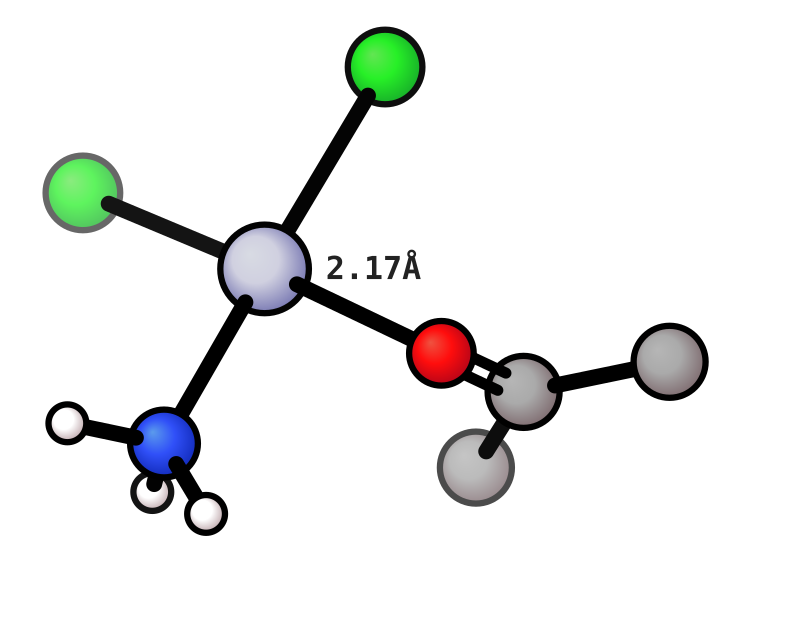

In [23]:
isos = rx.metal("N->[Pt](Cl)Cl.CC(C)=O", "square_planar")  # 3 donors + acetone -> one vacant site
iso = isos.select(index=0)  # the cis isomer (both Cl cis)
O = next(a.GetIdx() for a in iso.mol.GetAtoms() if a.GetSymbol() == "O")
seated = rx.embed(iso, coordinate=O, n=3).mc(preset="ensemble").prune()
print(f"acetone O seated: Pt-O = {seated.measure((iso.metal, O))['mean']:.2f} Å  ({len(seated)} confs)")
xyzrender.render(xyz(seated), no_hy=True, labels=[f"{iso.metal + 1} {O + 1} d"])  # label the new Pt-O coordinative bond

**Switching the binding mode:** the same substrate can grip *bifunctionally* — the O coordinated to Pt **and** an amine N–H···O hydrogen bond held at the same time. Two contacts, one pose (both dotted, both labelled).

rxembed | embed[square_planar: N0 Cl2 Cl3 · coord@[7]]: 3 seeds
rxembed | mc: preset='rapid' on a constrained system under-samples (pose-mode is rotor-only); 'ensemble' (the default) is recommended for a constrained run
rxembed | mc: 6 atom(s) constrained -> openconf runs POSE-FROZEN (rotor-only; low-mode/ring/global moves off) so the held contact is never broken


rxembed | mc: +2 (openconf 'rapid', pose-constrained around seeds; total 5)
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.1, 0.2, 0.5, 1.1] | window=250 -> all within window
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.1, 0.4, 0.5, 0.6, 0.7, 0.9] | window=250 -> all within window
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.3, 0.3, 0.6, 1.3, 2.4, 3.1] | window=250 -> all within window
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.2, 0.7, 0.7, 1.0, 3.6, 3.7] | window=250 -> all within window
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.1, 0.6, 0.9, 1.0, 2.1, 2.9] | window=250 -> all within window
rxembed | minimize: relax ΔE spread (kcal/mol above min): [0.0, 0.0, 0.2, 0.7, 1.5, 2.0, 3.4] | window=250 -> all within window
rxembed | minimize: re-embedded to 0/5 clean geometries
rxembed | prune[rmsd]: 5 -> 4  (merged 1 near-duplicates; see .duplicates())
no bond between atoms 9 and 8 - p

bifunctional: Pt-O 2.17 Å + H-O 2.20 Å, N-H-O 140°


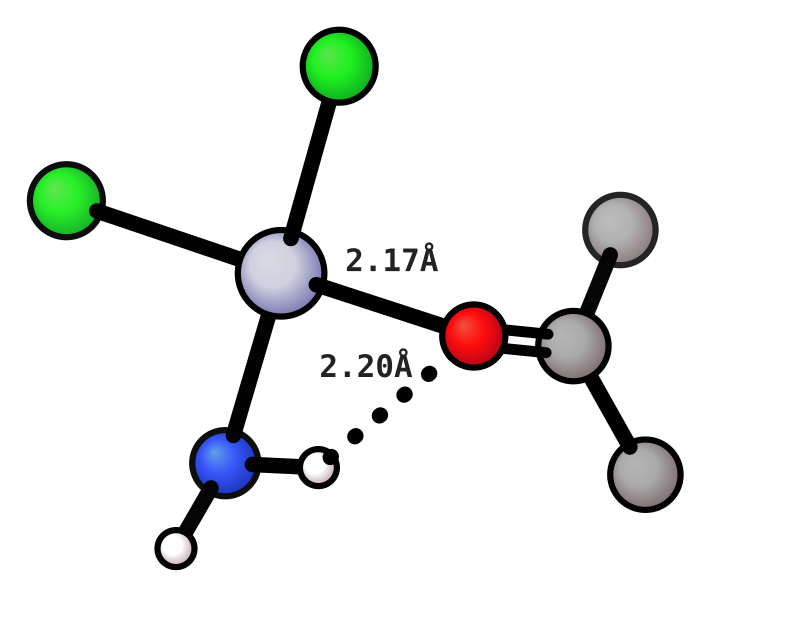

In [ ]:
N = next(d for d in iso.donors if iso.mol.GetAtomWithIdx(d).GetSymbol() == "N")
H = next(n.GetIdx() for n in iso.mol.GetAtomWithIdx(N).GetNeighbors() if n.GetAtomicNum() == 1)
grip = rx.Contact(distances={(min(H, O), max(H, O)): (1.6, 2.2)}, angles={(N, H, O): (140.0, 180.0)}, label="NH..O")
bi = rx.embed(iso, coordinate=O, contacts=grip, n=3).mc(preset="rapid").prune()
print(
    f"bifunctional: Pt-O {bi.measure((iso.metal, O))['mean']:.2f} Å + H-O {bi.measure((H, O))['mean']:.2f} Å, "
    f"N-H-O {bi.measure((N, H, O))['mean']:.0f}°"
)
xyzrender.render(
    xyz(bi),
    no_hy=True,
    nci_bonds=[(H + 1, O + 1)],  # only the H...O is an NCI (dotted); Pt-O is a normal bond
    labels=[f"{iso.metal + 1} {O + 1} d", f"{H + 1} {O + 1} d"],
)